In [1]:
import piplite
await piplite.install(['numpy','pandas'])
await piplite.install(['seaborn'])

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

Matplotlib is building the font cache; this may take a moment.


In [15]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [16]:
boston_df=pd.read_csv(boston_url)

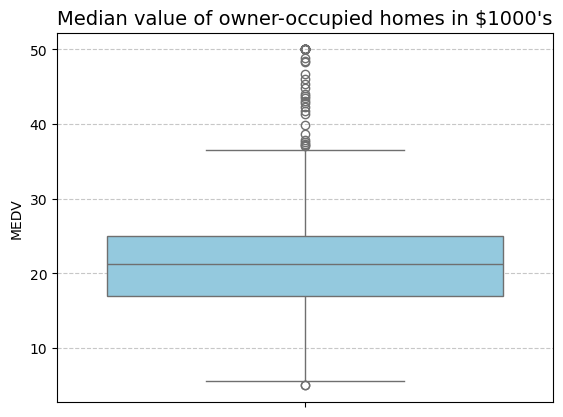

In [38]:
# For the "Median value of owner-occupied homes" provide a boxplot
sns.boxplot(boston_df["MEDV"], color='skyblue')
plt.title("Median value of owner-occupied homes in $1000's", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Median value of owner-occupied homes shows the distribution of median home values, with most values concentrated between the lower and upper quartiles. 
#The central line indicates the median price, while plenty outliers above the upper whisker suggest dozens homes are significantly more expensive that the rest.
#Overall, the data appears moderately skewed, with a longer tail toward higher property values.

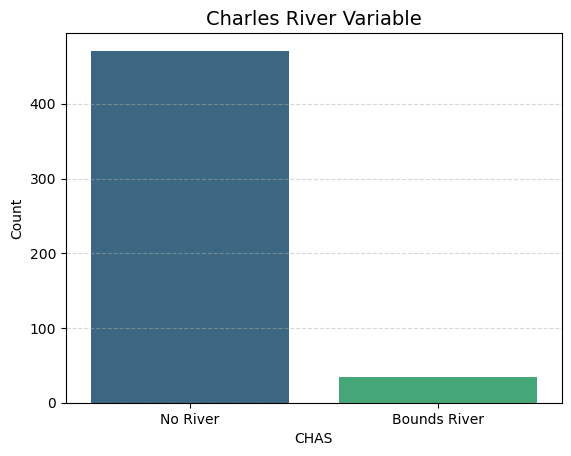

In [24]:
#Bar plot for the Charles River variables

#Count the occurences of CHAS values.
chas_counts = boston_df['CHAS'].value_counts().reset_index()
chas_counts.columns = ['CHAS', 'Count']

#Bar plot
sns.barplot(data=chas_counts, x='CHAS', y='Count', hue='CHAS', palette='viridis', legend=False)
plt.title('Charles River Variable', fontsize=14)
plt.xlabel('CHAS')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No River', 'Bounds River'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

In [ ]:
#Charles River variable represents number of houses with are bounded or not bounded with the Charles River.
#Significantly much more houses are not bounded with the Charles River

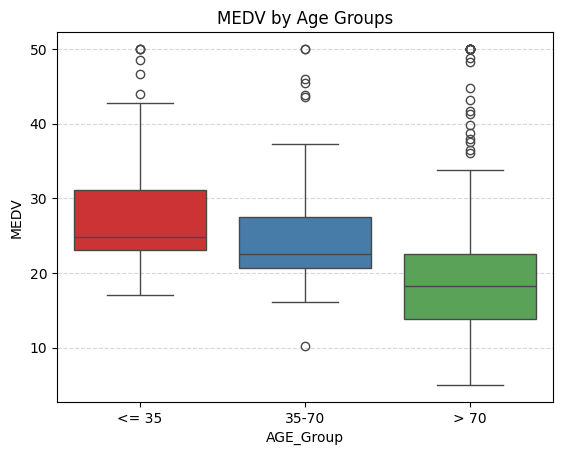

In [19]:
#Box plot for the MEDV vs the AGE variablees

#Create AGE groups
bins = [0, 35, 70, boston_df['AGE'].max()]
labels = ['<= 35', '35-70', '> 70']
boston_df['AGE_Group'] = pd.cut(boston_df['AGE'], bins=bins, labels=labels)

#Box plot
sns.boxplot(data=boston_df, x='AGE_Group', y='MEDV', hue='AGE_Group', palette='Set1')
plt.title("MEDV by Age Groups")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
#MEDV variable vs the AGE variable shows that homes in newer buildings (<= 35 years) tend to have higher median values and fewer outliers. 
#As building age increases, median home values generally decline, with older properties showing more variability and lower price ranges.

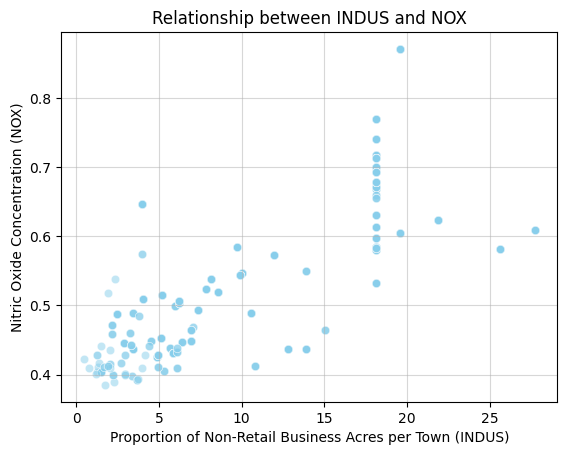

In [25]:

#Scatter plot
sns.scatterplot(x=boston_df['INDUS'], y=boston_df['NOX'], color='skyblue', alpha=0.5)
plt.title('Relationship between INDUS and NOX')
plt.xlabel('Proportion of Non-Retail Business Acres per Town (INDUS)')
plt.ylabel('Nitric Oxide Concentration (NOX)')
plt.grid(alpha=0.5)
plt.show()

In [39]:
#Relashion ship between INDUS and NOX indicates that industrial zones contribute to air pollution.
#More industrial land is assosiated with higher pollution levels. 

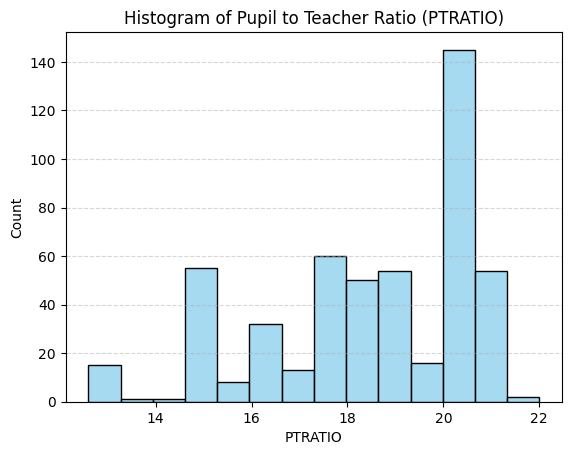

In [27]:
#Histogram for PTRATIO
sns.histplot(boston_df['PTRATIO'], color='skyblue')
plt.title("Histogram of Pupil to Teacher Ratio (PTRATIO)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
#The histogram shows that most pupil-to-teacher ratios in the dataset cluster around 18 to 20, indicating a common class size range.
#The distribution is fairly tight, suggesting limited varation in student-teacher ratios across town.

In [29]:
# H0: There is no significant difference in the median value of houses bounded by the Charles river.
# H1: There is a significant difference in the median value of houses bounded by the Charles river.

#Split MEDV based on CHAS
medv_chas_1 = boston_df[boston_df['CHAS'] == 1]['MEDV']
medv_chas_0 = boston_df[boston_df['CHAS'] == 0]['MEDV']

#Perform independent t-test
t_stat, p_value = stats.ttest_ind(medv_chas_0, medv_chas_1, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

#Conclusion
alpha = 0.05
if p_value < alpha:
    print("Conclusion: There is a significant difference in the median value of houses bounded by the Charles river.")
else:
    print("Conclusion: There is no significant difference in the median value of houses bounded by the Charles river.")

t-statistic: -3.113291312794837
p-value: 0.0035671700981375174
Conclusion: There is a significant difference in the median value of houses bounded by the Charles river.


In [32]:
#H0: There is no significant difference in MEDV among AGE groups.
#H1: There is a significant difference in MEDV among AGE groups.

#Create AGE groups
bins = [0, 35, 70, boston_df['AGE'].max()]
labels = ['<= 35', '35-70', '> 70']
boston_df['AGE_group'] = pd.cut(boston_df['AGE'], bins=bins, labels=labels)

#Separate MEDV values by AGE groups
group1 = boston_df[boston_df['AGE_group'] == '<= 35']['MEDV']
group2 = boston_df[boston_df['AGE_group'] == '35-70']['MEDV']
group3 = boston_df[boston_df['AGE_group'] == '> 70']['MEDV']

#Perform ANOVA
f_stat, p_value = stats.f_oneway(group1, group2, group3)

print("ANOVA test")
print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Conclusion: There is a significant difference in MEDV among AGE groups.")
else:
    print("Conclusion: There is no significant difference in MEDV among AGE groups.")


ANOVA test
F-statistic: 36.40764999196599
P-value: 1.7105011022702984e-15
Conclusion: There is a significant difference in MEDV among AGE groups.


In [34]:
#H0: There is no linear relationship between NOX and INDUS.
#H1: There is a linear relationship between NOX and INDUS.

#Perform Pearson correlation
corr_coef, p_value = stats.pearsonr(boston_df['INDUS'], boston_df['NOX'])

print("Pearson Correlation Test")
print("correlation coefficient:", corr_coef)
print("p-value:", p_value)

#Conclusion
if p_value < 0.05:
    print("There is a linear relationship between NOX and INDUS.")
else:
    print("There is no linear relationship between NOX and INDUS.")


Pearson Correlation Test
correlation coefficient: 0.763651446920915
p-value: 7.913361061241112e-98
There is a linear relationship between NOX and INDUS.


In [42]:
x = boston_df[['DIS']]
y = boston_df['MEDV']
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           1.21e-08
Time:                        13:10:16   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

In [45]:
#Coefficient of DIS is 1.0916
#Statistics suggest that increasing the distance to employment centers does influence house prices that much.